# Лабораторная работа № 4

## Задания

![tasks](./tasks.png)

### Прямая задача

$$
\left\{ \begin{aligned} 
  &\frac{1}{c^2}U_{tt} = ΔU \\
  &U|_{t = 0} = f \\
  &{U_t|}_{t = 0} = 0 \\
  &{U_n|}_{∂Ω × [0, T]} = 0
\end{aligned} \right.
$$

$$
Ω = [0, L]^2
$$

$U_n$ - производная по нормали

Её решение: $U^f$

Численная схема для $U$

$$
\frac{U^{i+1}_{j,k} - 2U^{i}_{j,k} + U^{i-1}_{j,k}}{c^2τ^2} = \frac{U^{i}_{j+1,k} - 2U^{i}_{j,k} + U^{i}_{j-1,k}}{h^2} + \frac{U^{i}_{j,k+1} - 2U^{i}_{j,k} + U^{i}_{j,k-1}}{h^2}
$$

$$
h = Δx = Δy
$$

$$
τ = Δt
$$

$$
U^0_{j,k} = f_{j,k}
$$

$$
U^1_{j,k} = f_{j.k}
$$

Условие Куранта

$$
τ ≤ \frac{h}{c\sqrt{2}}
$$

### Обратная задача

$$
\left\{ \begin{aligned} 
  &\frac{1}{c^2}V_{tt} = ΔV \\
  &V|_{t = T} = 0 \\
  &{V_t|}_{t = T} = 0 \\
  &{V|}_{∂Ω × [0, T]} = U^f
\end{aligned} \right.
$$

Требуется найти $f$, зная решение $U^f$

Численная схема для $V$

$$
\frac{V^{i+1}_{j,k} - 2V^{i}_{j,k} + V^{i-1}_{j,k}}{c^2τ^2} = \frac{V^{i}_{j+1,k} - 2V^{i}_{j,k} + V^{i}_{j-1,k}}{h^2} + \frac{V^{i}_{j,k+1} - 2V^{i}_{j,k} + V^{i}_{j,k-1}}{h^2}
$$

$$
h = Δx = Δy
$$

$$
τ = Δt
$$

$$
V^T_{j,k} = 0
$$

$$
V^{T+1}_{j,k} = 0
$$

## Библиотеки

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Реализация

### Вводные данные

In [2]:
L = 1
tmax = 20
c = 1
x0, y0 = 0.5, 0.5
r = 0.25
h = 0.01

tau = h / (c * np.sqrt(2))  # условие куранта

X = np.arange(0, L+h, h)
Y = np.arange(0, L+h, h)
T = np.arange(0, tmax+tau, tau)

def heaviside(t):  # функция Хевисайда
    if t > 0:
        return 1

    return 0

def f(x,y):
    return heaviside(r**2 - (x - x0)**2 - (y - y0)**2)

### Численное решение прямой задачи

Берём размерность на 2 больше, т.к. нужно захватить значения левее нижней границы и значения правее верхней границы для x и y. Эти значения найдём из условий Неймана

In [3]:
dimX, dimY, dimT = X.shape[0], Y.shape[0], T.shape[0]

U = np.zeros((dimX+2, dimY+2, dimT), dtype=np.float64)

In [4]:
print(dimX, dimY, dimT)
print("Iterations:", dimX*dimY*dimT)

101 101 2830
Iterations: 28868830


In [5]:
q = c**2 * tau**2 / h**2

for i in range(dimT): 
    for j in range(1, dimX+1):
        for k in range(1, dimY+1):
            if i == 0 or i == 1:  # значения в моменты времени 0 и 1
                U[j][k][i] = f(X[j-1], Y[k-1])

            else:  # значения по сетке
                U[j][k][i] = 2*U[j][k][i-1] - U[j][k][i-2] + q*(U[j+1][k][i-1] + U[j-1][k][i-1] + U[j][k+1][i-1] + U[j][k-1][i-1] - 4*U[j][k][i-1])
    
    # Значения из условий Неймана
    
    U[0, :, i] = U[2, :, i]
    U[dimX+1, :, i] = U[dimX-1, :, i]
    U[:, 0, i] = U[:, 2, i]
    U[:, dimY+1, i] = U[:, dimY-1, i]

### Численное решение обратной задачи

In [6]:
V = np.zeros((dimX, dimY, dimT+1), dtype=np.float64)

Значения на границах x = 0, x = L, y = 0, y = L равны решению U

Значения в моменты времени T+1 и T равны 0

Всё это следует из условий системы

In [7]:
for i in range(dimT-1):
    V[0, :, i] = U[1, 1:dimY+1, i]
    V[dimX-1, :, i] = U[dimX, 1:dimY+1, i]
    V[:, 0, i] = U[1:dimX+1, 1, i]
    V[:, dimY-1, i] = U[1:dimX+1, dimY, i]

Остальные значения по численной схеме

In [8]:
for i in range(dimT-2, -1, -1):  # идём по времени назад
    for j in range(1, dimX-1):
        for k in range(1, dimY-1):
            V[j][k][i] = 2*V[j][k][i+1] - V[j][k][i+2] + q*(V[j+1][k][i+1] + V[j-1][k][i+1] + V[j][k+1][i+1] + V[j][k-1][i+1] - 4*V[j][k][i+1])

### Сравнения исходной f и восстановленной

По идее, V в момент времени 0 и будет функцией f

<Figure size 1000x600 with 0 Axes>

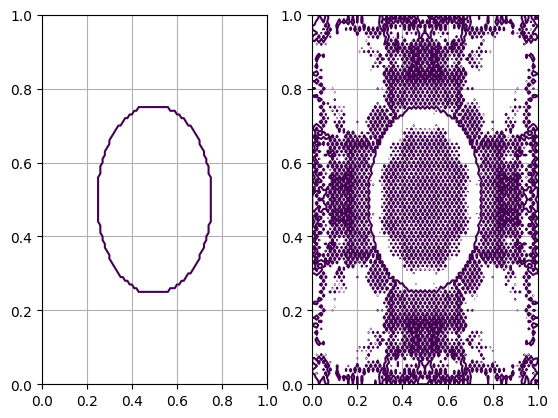

In [9]:
plt.figure(figsize=(10, 6))

fig, axes = plt.subplots(1, 2)

z1 = np.zeros((dimX, dimY))
z2 = np.zeros((dimX, dimY))

for j in range(dimX):
    for k in range(dimY):
        z1[j][k] = f(X[j], Y[k])
        z2[j][k] = V[j][k][0]

axes[0].contour(X, Y, z1, levels=[0])
axes[1].contour(X, Y, z2, levels=[0])

axes[0].grid()
axes[1].grid()

plt.show()

Более плавная картина

<Figure size 1000x600 with 0 Axes>

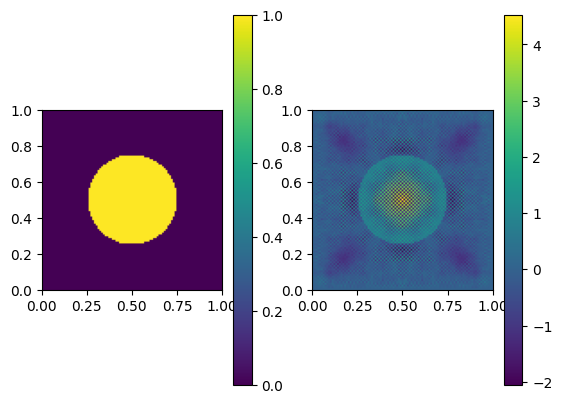

In [12]:
plt.figure(figsize=(10, 6))

fig, axes = plt.subplots(1, 2)

im1 = axes[0].imshow(z1, origin='lower', extent=[0,L,0,L])
im2 = axes[1].imshow(z2, origin='lower', extent=[0,L,0,L])

plt.colorbar(im1, ax=axes[0])
plt.colorbar(im2, ax=axes[1])

plt.show()